In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('/Users/taktakro/Desktop/SmallProjects_PY/NLP/IMDB Dataset of 50K Movie Reviews/IMDB Dataset.csv')

In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
data['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [5]:
from bs4 import BeautifulSoup

In [6]:
def text_cleaner(text):
    #HTML to text format
    soup = BeautifulSoup(text)
    text = soup.get_text()
    return text

In [7]:
data['review'] = data['review'].apply(text_cleaner)

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()
y = le.fit_transform(data['sentiment'])

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['review'])

In [12]:
vocab_len = len(tokenizer.word_index) + 1

In [13]:
vocab_len

126507

In [14]:
encoded = tokenizer.texts_to_sequences(data['review'])

In [15]:
list_len = []
for seq in encoded:
    list_len.append(len(seq))

max_len = max(list_len)

In [16]:
max_len

2466

In [18]:
import numpy as np
np.average(list_len)

np.float64(230.93756)

In [19]:
np.median(list_len)

np.float64(173.0)

In [20]:
import matplotlib.pyplot as plt

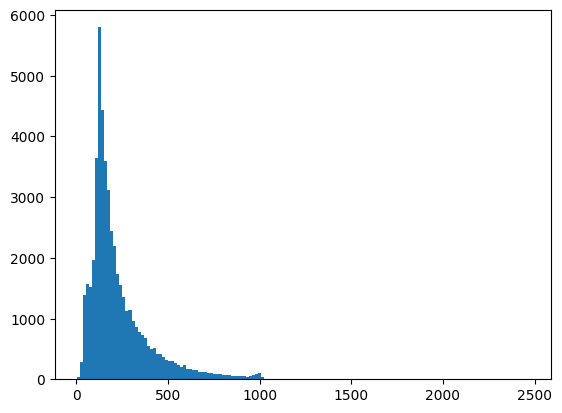

In [33]:
plt.hist(list_len, bins=150)
plt.show()

In [25]:
list_len.sort()

In [27]:
len(list_len)

50000

In [38]:
len(list_len)

50000

In [39]:
max_len=400

In [40]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [41]:
X = pad_sequences(encoded,maxlen=max_len,padding='post')

In [42]:
X

array([[  26,    4,    1, ...,    0,    0,    0],
       [   3,  392,  119, ...,    0,    0,    0],
       [   9,  189,   10, ...,    0,    0,    0],
       ...,
       [   9,  234,    3, ...,    0,    0,    0],
       [ 144,  165,    5, ...,    0,    0,    0],
       [  53,   26, 5889, ...,    0,    0,    0]], dtype=int32)

In [43]:
X.shape

(50000, 400)

In [44]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.6)

In [55]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding,Conv1D,MaxPool1D,Flatten,Dense,Dropout, Input
from tensorflow.keras.models import Sequential

In [56]:
reg = tf.keras.regularizers.l2(0.003)

In [57]:
model = Sequential()
model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=vocab_len,output_dim=50,
                    embeddings_regularizer=reg))
model.add(Dropout(0.5))
model.add(Conv1D(filters=64,kernel_size=4,padding='same',activation='relu'))
model.add(Dropout(0.25))
model.add(MaxPool1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

In [58]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 400, 50)        │     6,325,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 400, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 400, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       819,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,157,543 (27.30 MB)

 Trainable params: 7,157,543 (27.30 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
#compile model
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.BinaryCrossentropy()
metric = tf.metrics.BinaryAccuracy()
model.compile(optimizer=opt,loss=loss,metrics=[metric])

In [ ]:
model.fit(X_train,y_train,batch_size=50,epochs=10,validation_split=0.2,verbose=2)

Epoch 1/10
640/640 - 10s - loss: 0.9743 - binary_accuracy: 0.7235 - val_loss: 0.5690 - val_binary_accuracy: 0.8565 - 10s/epoch - 16ms/step
Epoch 2/10
640/640 - 8s - loss: 0.5716 - binary_accuracy: 0.8610 - val_loss: 0.5422 - val_binary_accuracy: 0.8751 - 8s/epoch - 13ms/step
Epoch 3/10
640/640 - 8s - loss: 0.5511 - binary_accuracy: 0.8781 - val_loss: 0.5570 - val_binary_accuracy: 0.8735 - 8s/epoch - 13ms/step
Epoch 4/10
640/640 - 9s - loss: 0.5474 - binary_accuracy: 0.8844 - val_loss: 0.5306 - val_binary_accuracy: 0.8894 - 9s/epoch - 14ms/step
Epoch 5/10
640/640 - 9s - loss: 0.5361 - binary_accuracy: 0.8936 - val_loss: 0.5321 - val_binary_accuracy: 0.8930 - 9s/epoch - 14ms/step
Epoch 6/10
640/640 - 8s - loss: 0.5346 - binary_accuracy: 0.8942 - val_loss: 0.5303 - val_binary_accuracy: 0.8972 - 8s/epoch - 13ms/step
Epoch 7/10
640/640 - 8s - loss: 0.5220 - binary_accuracy: 0.8980 - val_loss: 0.5280 - val_binary_accuracy: 0.8934 - 8s/epoch - 13ms/step
Epoch 8/10
640/640 - 9s - loss: 0.5274 

In [61]:
model.evaluate(X_test,y_test)

938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.4938 - loss: 16.5116


[16.51157569885254, 0.49950000643730164]